**pandas** is a Python library for data manipulation and analysis. It provides data structures and operations for working with numerical tables and time series.

In this notebook, you will learn how to load a dataset and explore, slice, clean, and manipulate it with pandas.

## 1.1 Installing and Importing Pandas

Run the cell below to install pandas if it isn't already installed in your environment. If it's already installed, this cell has no effect.

In [ ]:
#!pip install pandas

Import pandas under the conventional alias `pd`.

In [ ]:
import pandas as pd

## 1.2 Importing a Dataset

This notebook uses `titanic.csv`, a dataset describing the passengers of the Titanic (age, sex, ticket class, whether they survived, etc.).

Run the cell below and upload `titanic.csv` (found in this notebook's folder in the repo) when prompted.

In [ ]:
from google.colab import files
uploaded = files.upload()  # select titanic.csv

Saving data.csv to data (1).csv


Load the uploaded CSV into a pandas DataFrame and print it.

In [ ]:
df = pd.read_csv('/content/data (1).csv')
print(df)

           id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0      842302         M        17.99         10.38          122.80     1001.0   
1      842517         M        20.57         17.77          132.90     1326.0   
2    84300903         M        19.69         21.25          130.00     1203.0   
3    84348301         M        11.42         20.38           77.58      386.1   
4    84358402         M        20.29         14.34          135.10     1297.0   
..        ...       ...          ...           ...             ...        ...   
564    926424         M        21.56         22.39          142.00     1479.0   
565    926682         M        20.13         28.25          131.20     1261.0   
566    926954         M        16.60         28.08          108.30      858.1   
567    927241         M        20.60         29.33          140.10     1265.0   
568     92751         B         7.76         24.54           47.92      181.0   

     smoothness_mean  compa

unrelevent column drop

In [ ]:
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Missing value check ও mean imputation

In [ ]:
import numpy as np

print("Missing values before:\n", df.isnull().sum()[df.isnull().sum() > 0])
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
print("Missing values after:", df.isnull().sum().sum())
df.head()

Missing values before:
 Series([], dtype: int64)
Missing values after: 0


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Categorical variable encode

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])   # M=1, B=0
print(dict(zip(le.classes_, le.transform(le.classes_))))
df.head()

{'B': np.int64(0), 'M': np.int64(1)}


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Feature and target separate

In [ ]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Min-Max Scaling on feature. not on target

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(X_scaled.head())
df.head()

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0     0.521037      0.022658        0.545989   0.363733         0.593753   
1     0.643144      0.272574        0.615783   0.501591         0.289880   
2     0.601496      0.390260        0.595743   0.449417         0.514309   
3     0.210090      0.360839        0.233501   0.102906         0.811321   
4     0.629893      0.156578        0.630986   0.489290         0.430351   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0          0.792037        0.703140             0.731113       0.686364   
1          0.181768        0.203608             0.348757       0.379798   
2          0.431017        0.462512             0.635686       0.509596   
3          0.811361        0.565604             0.522863       0.776263   
4          0.347893        0.463918             0.518390       0.378283   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


preprocessing

In [ ]:
df = pd.read_csv('data.csv')
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  # M=1, B=0

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
df_scaled = X_scaled.copy()
df_scaled['diagnosis'] = y.values

Violin Plot

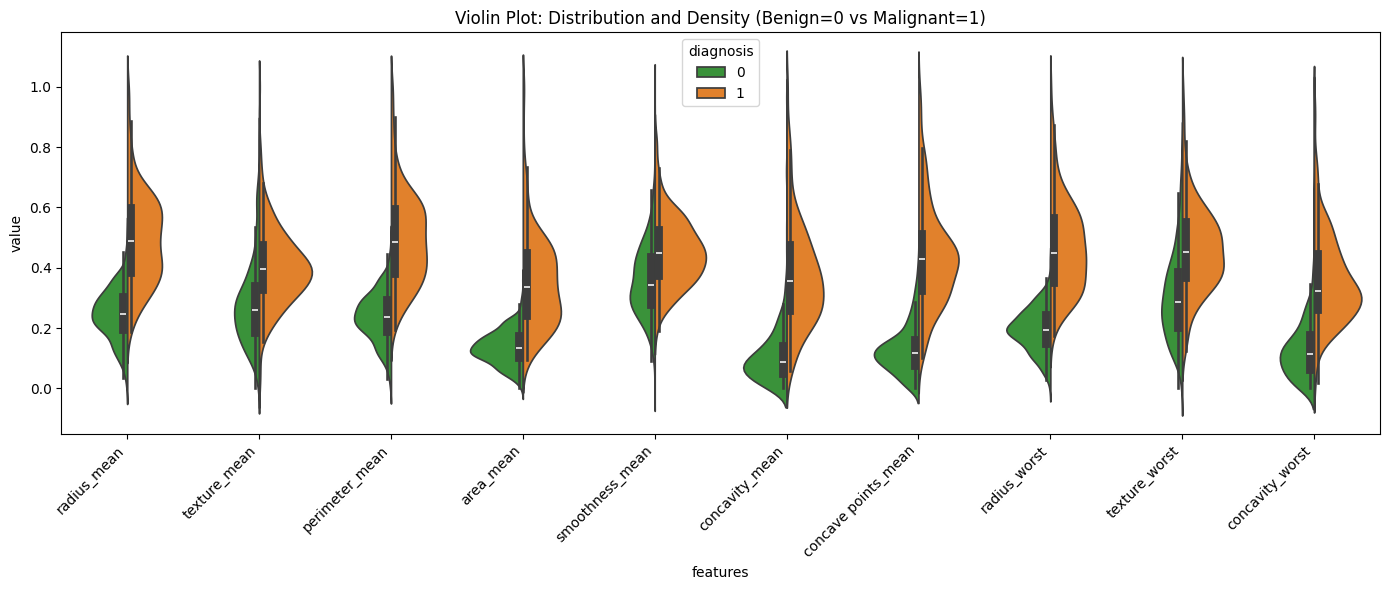

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
                      'smoothness_mean', 'concavity_mean', 'concave points_mean',
                      'radius_worst', 'texture_worst', 'concavity_worst']

melted = df_scaled.melt(id_vars='diagnosis', value_vars=selected_features,
                         var_name='features', value_name='value')

plt.figure(figsize=(14, 6))
sns.violinplot(x='features', y='value', hue='diagnosis', data=melted, split=True,
               palette=['#2ca02c', '#ff7f0e'])
plt.xticks(rotation=45, ha='right')
plt.title('Violin Plot: Distribution and Density (Benign=0 vs Malignant=1)')
plt.tight_layout()
plt.show()

Correlation Heatmap

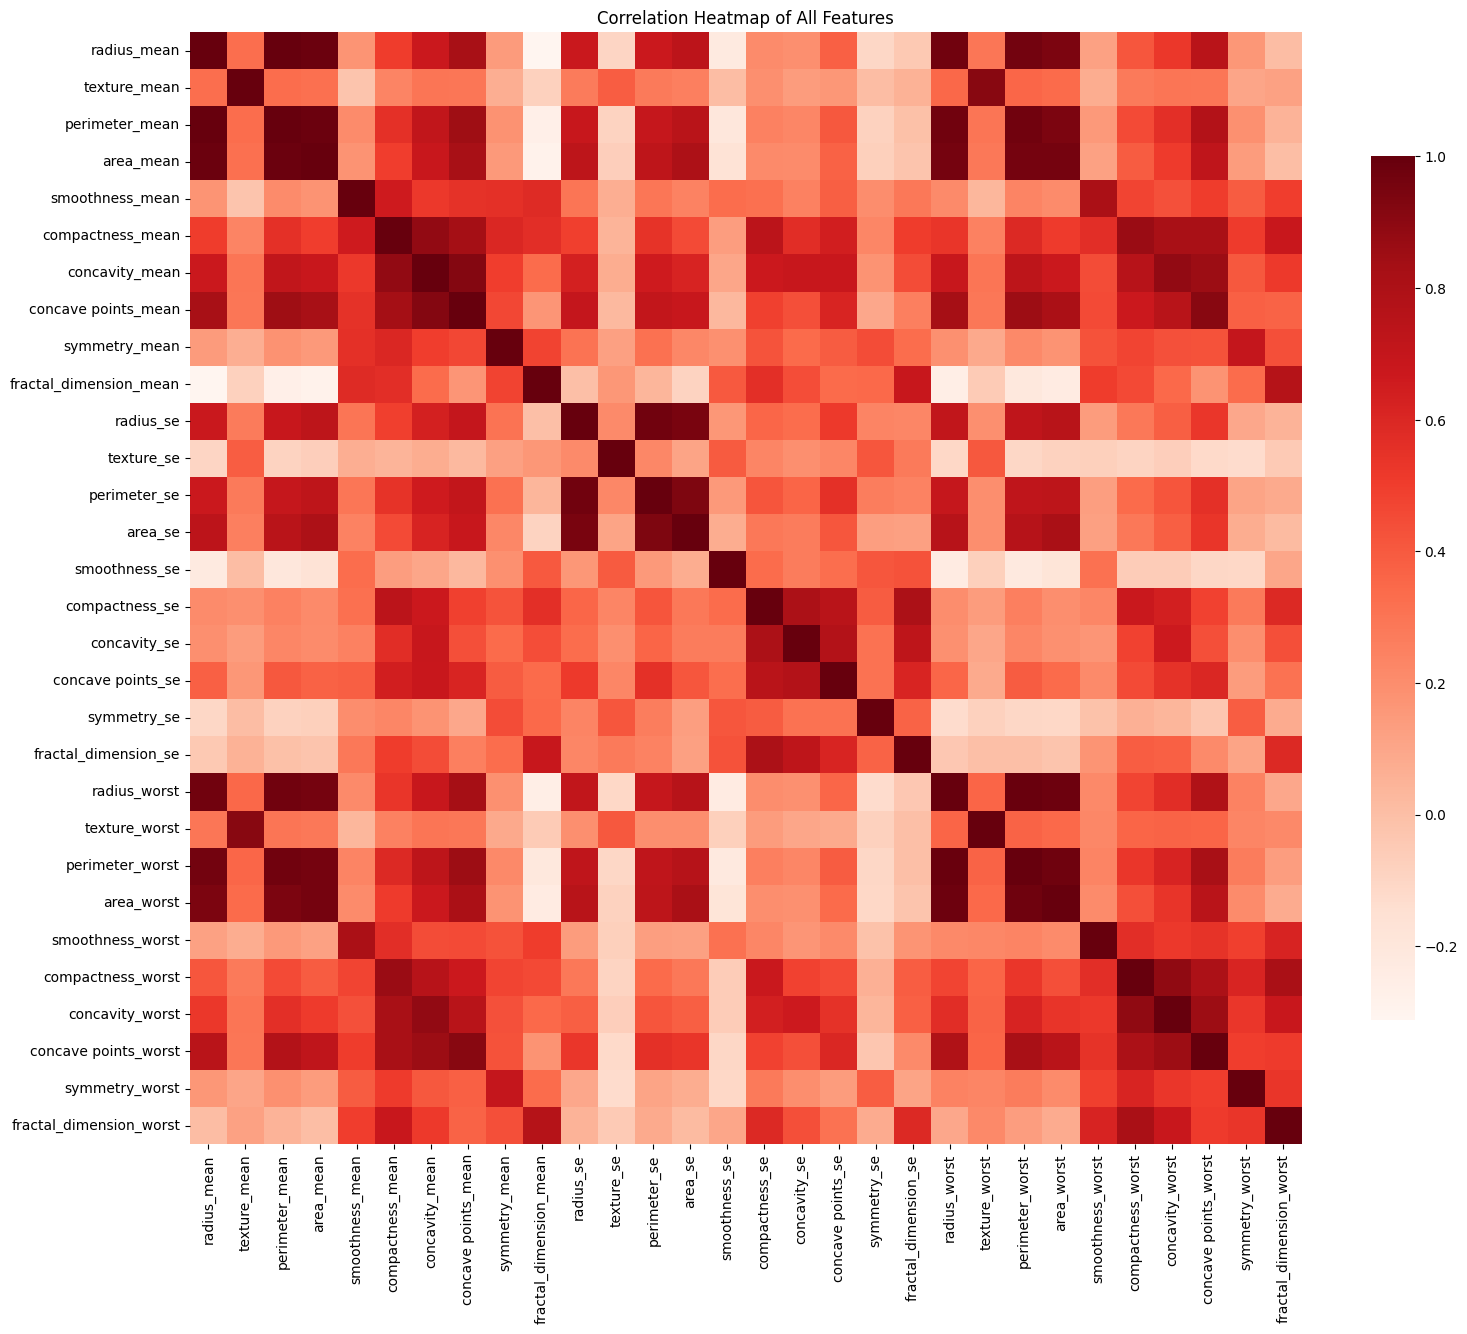

In [ ]:
corr_matrix = X.corr()  # Pearson correlation coefficient

plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, cmap='Reds', annot=False, square=True, cbar_kws={'shrink': 0.7})
plt.title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.show()

Highly correlated pairs

In [ ]:
threshold = 0.9
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j],
                                     round(corr_matrix.iloc[i, j], 3)))

print(f"Total highly correlated pairs (|corr| > {threshold}): {len(high_corr_pairs)}")
for pair in high_corr_pairs:
    print(pair)

Total highly correlated pairs (|corr| > 0.9): 21
('radius_mean', 'perimeter_mean', np.float64(0.998))
('radius_mean', 'area_mean', np.float64(0.987))
('radius_mean', 'radius_worst', np.float64(0.97))
('radius_mean', 'perimeter_worst', np.float64(0.965))
('radius_mean', 'area_worst', np.float64(0.941))
('texture_mean', 'texture_worst', np.float64(0.912))
('perimeter_mean', 'area_mean', np.float64(0.987))
('perimeter_mean', 'radius_worst', np.float64(0.969))
('perimeter_mean', 'perimeter_worst', np.float64(0.97))
('perimeter_mean', 'area_worst', np.float64(0.942))
('area_mean', 'radius_worst', np.float64(0.963))
('area_mean', 'perimeter_worst', np.float64(0.959))
('area_mean', 'area_worst', np.float64(0.959))
('concavity_mean', 'concave points_mean', np.float64(0.921))
('concave points_mean', 'concave points_worst', np.float64(0.91))
('radius_se', 'perimeter_se', np.float64(0.973))
('radius_se', 'area_se', np.float64(0.952))
('perimeter_se', 'area_se', np.float64(0.938))
('radius_worst',

 Correlation-based elimination(eq,4)

In [ ]:
threshold_corr = 0.9
corr_matrix = X.corr()
to_drop = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold_corr:
            to_drop.add(corr_matrix.columns[j])
X_reduced = X_scaled.drop(columns=list(to_drop))
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


 Chi-Square (Eq. 5)

In [ ]:
from sklearn.feature_selection import chi2

feature_names = X_scaled.columns
votes = pd.DataFrame({'Feature': feature_names})
votes['Chi_square'] = 0

chi_scores, p_values = chi2(X_scaled, y)
chi_series = pd.Series(chi_scores, index=feature_names)
top_chi = chi_series.sort_values(ascending=False).head(16).index.tolist()
votes.loc[votes['Feature'].isin(top_chi), 'Chi_square'] = 1
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


 Random Forest importance (Eq. 6)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_scaled, y)
rf_importance = pd.Series(rf.feature_importances_, index=feature_names)
top_rf = rf_importance.sort_values(ascending=False).head(16).index.tolist()
votes.loc[votes['Feature'].isin(top_rf), 'RF'] = 1
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


 Extra Trees

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(n_estimators=200, random_state=42)
et.fit(X_scaled, y)
et_importance = pd.Series(et.feature_importances_, index=feature_names)
top_et = et_importance.sort_values(ascending=False).head(16).index.tolist()
votes.loc[votes['Feature'].isin(top_et), 'ExtraTrees'] = 1
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


5. RFE

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

rfe = RFE(LogisticRegression(max_iter=5000), n_features_to_select=16)
rfe.fit(X_scaled, y)
top_rfe = X_scaled.columns[rfe.support_].tolist()
votes.loc[votes['Feature'].isin(top_rfe), 'RFE'] = 1
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


 7. Lasso (L1) (Eq. 7)

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
# LogisticRegression was imported in a previous cell, assuming it's available

cv = StratifiedKFold(5)
rfecv = RFECV(LogisticRegression(max_iter=5000), step=1, cv=cv, min_features_to_select=10)
rfecv.fit(X_scaled, y)
top_rfecv = X_scaled.columns[rfecv.support_].tolist()
votes.loc[votes['Feature'].isin(top_rfecv), 'RFECV'] = 1
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Final voting score (Table I)

In [ ]:
from sklearn.linear_model import LogisticRegression

lasso_model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=5000)
lasso_model.fit(X_scaled, y)

lasso_features = X_scaled.columns[lasso_model.coef_[0] != 0].tolist()
votes['L1'] = 0
votes.loc[votes['Feature'].isin(lasso_features), 'L1'] = 1

votes['Final_R_score'] = votes[['Chi_square', 'RF', 'ExtraTrees', 'RFE', 'RFECV', 'L1']].sum(axis=1)
votes = votes.sort_values('Final_R_score', ascending=False).reset_index(drop=True)
print(votes.to_string(index=False))

                Feature  Chi_square  RF  ExtraTrees  RFE  RFECV  L1  Final_R_score
    concave points_mean           1 1.0         1.0  1.0    1.0   1            6.0
           radius_worst           1 1.0         1.0  1.0    1.0   1            6.0
          texture_worst           1 1.0         1.0  1.0    1.0   1            6.0
   concave points_worst           1 1.0         1.0  1.0    1.0   1            6.0
              area_mean           1 1.0         1.0  1.0    1.0   0            5.0
            radius_mean           1 1.0         1.0  1.0    1.0   0            5.0
        perimeter_worst           1 1.0         1.0  1.0    1.0   0            5.0
         perimeter_mean           1 1.0         1.0  1.0    1.0   0            5.0
        concavity_worst           1 1.0         1.0  1.0    1.0   0            5.0
             area_worst           1 1.0         1.0  1.0    1.0   0            5.0
         concavity_mean           1 1.0         1.0  1.0    1.0   0            5.0
    

Final 16 features

In [ ]:
final_16 = votes.head(16)['Feature'].tolist()
print("Final 16 selected features:", final_16)


Final 16 selected features: ['concave points_mean', 'radius_worst', 'texture_worst', 'concave points_worst', 'area_mean', 'radius_mean', 'perimeter_worst', 'perimeter_mean', 'concavity_worst', 'area_worst', 'concavity_mean', 'smoothness_worst', 'radius_se', 'area_se', 'symmetry_worst', 'texture_mean']


Fig. 4 style plot

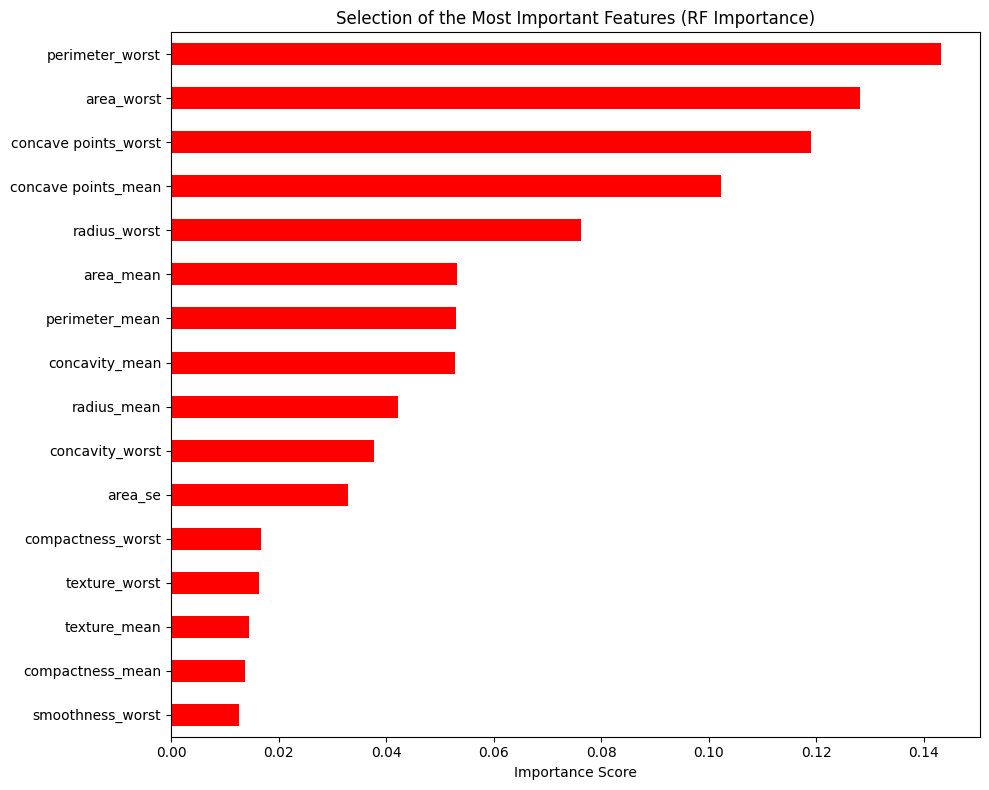

In [ ]:
plt.figure(figsize=(10, 8))
rf_importance.sort_values(ascending=False).head(16).plot(kind='barh', color='red')
plt.gca().invert_yaxis()
plt.title('Selection of the Most Important Features (RF Importance)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
jhklytf